In [55]:
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
df = pd.read_csv('data/houses.csv')
df.shape

(4000, 32)

In [57]:
df = df.replace('-', pd.NA)

In [58]:
df['price'] = df['price'].str.replace('RM', '').str.replace(' ', '').pipe(pd.to_numeric, errors='coerce')

In [59]:
df['Property Size'] = df['Property Size'].str.replace('sq.ft.', '').str.strip().pipe(pd.to_numeric, errors='coerce')

In [60]:
df['Bedroom'] = pd.to_numeric(df['Bedroom'], errors='coerce')
df['Bathroom'] = pd.to_numeric(df['Bathroom'], errors='coerce')

In [61]:
df['state'] = df['Address'].str.split(',').str[-1].str.strip()

In [62]:
df['facility_count'] = df['Facilities'].str.split(',').str.len().astype('Int64')

In [63]:
df['price_per_sqft'] = df['price'] / df['Property Size']

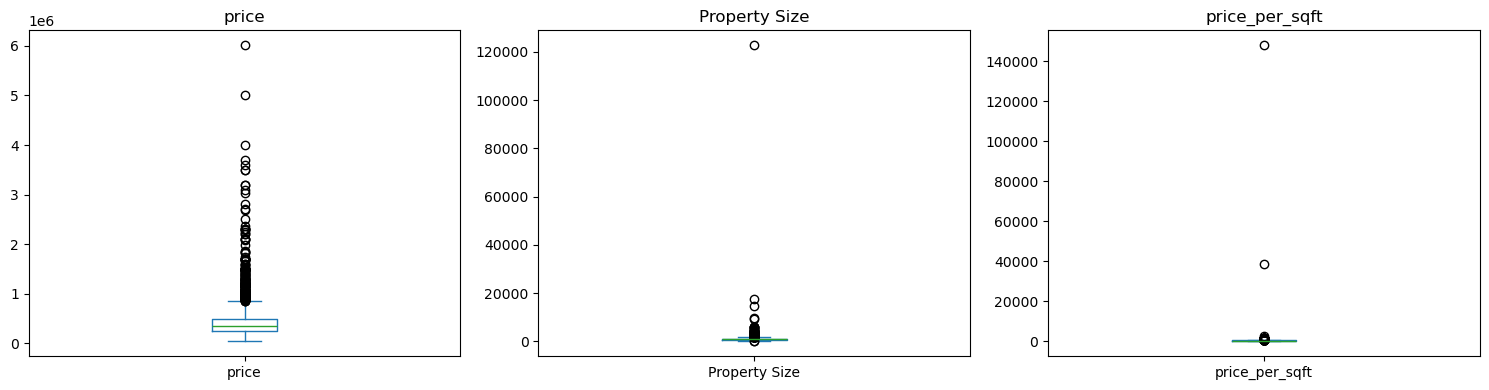

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['price'].plot(kind='box', ax=axes[0])
axes[0].set_title('price')
df['Property Size'].plot(kind='box', ax=axes[1])
axes[1].set_title('Property Size')
df['price_per_sqft'].plot(kind='box', ax=axes[2])
axes[2].set_title('price_per_sqft')
plt.tight_layout()

In [65]:
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['price_per_sqft'] >= Q1 - 1.5 * IQR) & (df['price_per_sqft'] <= Q3 + 1.5 * IQR)]
df.shape

(3839, 35)

In [66]:
df['Completion Year'] = pd.to_numeric(df['Completion Year'], errors='coerce')

In [67]:
df = df.drop(columns=['Ad List', 'Firm Number', 'REN Number', 'Firm Type', 'description', 'Category'])

In [68]:
proximity_cols = ['Highway', 'Hospital', 'Nearby Railway Station', 'Nearby Mall',
                  'Nearby School', 'Railway Station', 'Mall', 'Bus Stop', 'Park', 'School']
df = df.drop(columns=proximity_cols)

In [69]:
df = df.dropna(subset=['price'])
df = df.drop_duplicates()
df.shape

(3604, 19)

In [70]:
df.dtypes

Bedroom            float64
Bathroom           float64
Property Size        int64
Facilities          object
Building Name       object
Developer           object
Tenure Type         object
Address             object
Completion Year    float64
# of Floors         object
Total Units         object
Property Type       object
Parking Lot         object
Floor Range         object
Land Title          object
price                int64
state               object
facility_count       Int64
price_per_sqft     float64
dtype: object

In [71]:
df.isnull().sum()

Bedroom               0
Bathroom              0
Property Size         0
Facilities          579
Building Name        76
Developer          1604
Tenure Type           0
Address              76
Completion Year    1849
# of Floors        1564
Total Units        1738
Property Type         0
Parking Lot        1111
Floor Range         952
Land Title            0
price                 0
state                76
facility_count      579
price_per_sqft        0
dtype: int64

In [72]:
df.head()

,Bedroom,Bathroom,Property Size,Facilities,Building Name,Developer,Tenure Type,Address,Completion Year,# of Floors,Total Units,Property Type,Parking Lot,Floor Range,Land Title,price,state,facility_count,price_per_sqft
0,4.0,2.0,1000,<NA>,Kenwingston Platz,Kenwingston Group,Freehold,"Jalan Gombak, Setapak, Kuala Lumpur",NaN,<NA>,<NA>,Service Residence,2,<NA>,Non Bumi Lot,340000,Kuala Lumpur,<NA>,340.000000
1,3.0,2.0,980,"Parking, Security, Swimming Pool, Playground, ...",Kenanga (Park View Court),<NA>,Freehold,"Jalan Kenanga 3/8, Melaka City, Melaka",NaN,<NA>,<NA>,Apartment,1,Low,Non Bumi Lot,250000,Melaka,6,255.102041
2,3.0,2.0,1000,"Playground, Minimart, Jogging Track, Barbeque ...",Sri Lavender Apartment,TLS Group,Freehold,"Jalan Sepakat Indah 2/1, Taman Sepakat Indah 2...",2007.0,13,445,Apartment,1,Medium,Non Bumi Lot,230000,Selangor,7,230.000000
3,3.0,1.0,592,"Parking, Playground, Minimart, Jogging Track",Flat Pandan Indah,<NA>,Leasehold,"jalan pandan indah 3/3, Selangor, Ampang",NaN,<NA>,<NA>,Flat,1,<NA>,Non Bumi Lot,158000,Ampang,4,266.891892
4,1.0,1.0,467,"Minimart, Gymnasium, Parking, Security",i-Soho @ i-City,i-Berhad,Freehold,"Jalan Plumbum 7/102, Shah Alam, Selangor",NaN,43,956,Studio,<NA>,Low,Bumi Lot,305000,Selangor,4,653.104925


In [73]:
df.to_csv('data/houses_cleaned.csv', index=False)